# EEG Project Sample Code: Data Loading, Retrieval Evaluation, and Reconstruction Evaluation

This notebook provides concise starter code for the course project. It demonstrates:

1. how to load the released EEG data from `train.pt` and `test.pt`,
2. how to evaluate **200-way zero-shot retrieval** with **Top-1** and **Top-5** accuracy, and
3. how to evaluate **image reconstruction** with the official TA evaluation function.

The project specification requires retrieval evaluation with **Top-1 Accuracy** and **Top-5 Accuracy**, and reconstruction evaluation with the official TA code including metrics such as **SSIM** and **CLIP-based evaluation**. The report should summarize results over **10 different random seeds** using **mean ± standard deviation**. 

## 1. Environment and Conventions

This notebook is written for a simple teaching setting:

- Only **EEG** signals are considered.
- A single subject is fixed by the released files `train.pt` and `test.pt`.
- Therefore, the loader does **not** expose `brain_key` or `subject_id` arguments.
- The core input is a tensor of shape **`[N, C, T]`**, where:
  - `N` is the number of samples,
  - `C` is the number of EEG channels,
  - `T` is the number of time points.

This is clearly a **multichannel time-series learning** problem.

For image pairing, the dataset provides an `image_id` for each EEG sample. Once `image_id` is known, the paired image name is also known. For example, identifiers such as `aardvark_01b` and `aardvark_04s` indicate the corresponding image stems. The image folder can be resolved from the identifier convention used in the released data, so **image loading is intentionally omitted in this notebook**.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import List, Literal, Optional, Sequence, Union

import datasets
import numpy as np
import torch

## 2. EEG Dataset Loader

The function below is a simplified version of the original helper:

- `brain_key` is removed, because students only need to handle **EEG**.
- `subject_ids` is removed, because the course project fixes one subject through the provided `train.pt` and `test.pt`.
- All dataset descriptions are kept generic and do not depend on any external project name.
- `selected_channels` is still supported, so students can work either with **all channels** or with a **chosen subset**.

In [2]:
def _selected_channel_indices_from_jsonl(
    selected_channels: Union[str, Sequence[str]],
    eeg_channel_jsonl: Union[str, Path],
) -> List[int]:
    """Map EEG channel names to channel indices.

    The JSONL file is expected to store channel metadata line by line.
    Each line may contain fields such as:
    - {"name": "F5"}
    - {"channel_name": "F5"}
    - {"label": "F5"}

    Parameters
    ----------
    selected_channels:
        A single channel name or a sequence of channel names.
    eeg_channel_jsonl:
        Path to the JSONL file that defines the EEG channel order.

    Returns
    -------
    List[int]
        The indices of the requested channels in the original EEG tensor.
    """
    if isinstance(selected_channels, str):
        selected_channels = [selected_channels]
    selected_channels = list(selected_channels)

    channel_names: List[str] = []
    with open(eeg_channel_jsonl, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            name = item.get("name") or item.get("channel_name") or item.get("label")
            if name is None:
                raise KeyError(
                    "Each JSONL record must contain one of: 'name', 'channel_name', or 'label'."
                )
            channel_names.append(str(name))

    name_to_index = {name: idx for idx, name in enumerate(channel_names)}

    missing = [ch for ch in selected_channels if ch not in name_to_index]
    if missing:
        raise ValueError(f"Unknown EEG channels: {missing}")

    return [name_to_index[ch] for ch in selected_channels]


def load_eeg_dataset(
    *,
    data_directory: Union[str, Path],
    split: Literal["train", "test"],
    avg_trials: bool = True,
    selected_channels: Optional[Union[str, Sequence[str]]] = None,
    eeg_channel_jsonl: Union[str, Path] = "image-eeg-data/EEG_CHANNELS.jsonl",
) -> datasets.Dataset:
    """Build a Hugging Face dataset for the released EEG data.

    The expected file structure is:

        data_directory/
        ├── train.pt
        └── test.pt
        └── EEG_CHANNELS.jsonl

    The returned dataset contains:
    - `eeg`: Array2D float32 with shape [C, T]
    - `image_id`: string

    Parameters
    ----------
    data_directory:
        Directory that stores `train.pt` and `test.pt`.
    split:
        Either `"train"` or `"test"`.
    avg_trials:
        If the loaded EEG tensor has shape `[N, TRIAL, C, T]`, average over the
        trial dimension and return `[N, C, T]`. If `False`, flatten trials into
        the sample dimension and return `[(N * TRIAL), C, T]`.
    selected_channels:
        Optional EEG channel subset. If provided, the loader keeps only the
        requested channels in the given order.
    eeg_channel_jsonl:
        JSONL file describing the EEG channel order.

    Returns
    -------
    datasets.Dataset
        A dataset with columns:
        - `eeg`: Array2D float32 [C, T]
        - `image_id`: string
    """
    pt_path = Path(data_directory).joinpath(f"{split}.pt")
    loaded = torch.load(str(pt_path), weights_only=False)

    x = torch.as_tensor(loaded["eeg"])  # [N, TRIAL, C, T] or [N, C, T]
    if x.ndim == 4:
        if avg_trials:
            x = x.mean(dim=1)  # [N, C, T]
        else:
            x = x.reshape(-1, *x.shape[2:])  # [N * TRIAL, C, T]
    elif x.ndim != 3:
        raise ValueError(f"Unexpected EEG shape: {tuple(x.shape)} in {pt_path}")

    if selected_channels is not None:
        sel_idx = _selected_channel_indices_from_jsonl(selected_channels, eeg_channel_jsonl)
        x = x[:, sel_idx, :]

    imgs = np.array(loaded["img"])
    if avg_trials:
        if imgs.ndim == 2:
            imgs = imgs[:, 0]
        imgs = imgs.reshape(-1)[: x.shape[0]]
    else:
        imgs = imgs.reshape(-1)

    image_ids = [Path(p).stem for p in imgs.tolist()]
    if len(image_ids) != x.shape[0]:
        raise ValueError(
            f"EEG/image mismatch: {x.shape[0]} vs {len(image_ids)} for {pt_path}"
        )

    x_np = x.float().cpu().numpy()  # [N, C, T]
    C, T = x_np.shape[1], x_np.shape[2]

    features = datasets.Features(
        {
            "eeg": datasets.Array2D(shape=(C, T), dtype="float32"),
            "image_id": datasets.Value("string"),
        }
    )

    ds = datasets.Dataset.from_dict(
        {
            "eeg": list(x_np),
            "image_id": image_ids,
        },
        features=features,
    )
    return ds

### 2.1 Example: load all EEG channels

This version keeps the full multichannel EEG time series.

In [3]:
train_ds_all = load_eeg_dataset(
    data_directory="image-eeg-data",
    split="train",
    avg_trials=True,
)

train_ds_all = train_ds_all.with_format("torch")

test_ds_all = load_eeg_dataset(
    data_directory="image-eeg-data",
    split="test",
    avg_trials=True,
)

test_ds_all = test_ds_all.with_format("torch")
print(train_ds_all)
print(test_ds_all)
print(train_ds_all[0]["eeg"].shape)  # expected: [C, T]
print(train_ds_all[0]["image_id"])

Dataset({
    features: ['eeg', 'image_id'],
    num_rows: 16540
})
Dataset({
    features: ['eeg', 'image_id'],
    num_rows: 200
})
torch.Size([63, 250])
aardvark_01b


### 2.2 Example: load a selected channel subset

This version keeps only four EEG channels: `["F5", "FC5", "FT10", "T7"]`.

Because the input remains an ordered signal over time, this still forms a very clear **time-series modeling** problem, now with a smaller channel dimension.

In [4]:
train_ds_subset = load_eeg_dataset(
    data_directory="image-eeg-data",
    split="train",
    avg_trials=True,
    selected_channels=["F5", "FC5", "FT10", "T7"],
    eeg_channel_jsonl="image-eeg-data/EEG_CHANNELS.jsonl",
)

train_ds_subset = train_ds_subset.with_format("torch")

print(train_ds_subset)
print(train_ds_subset[0]["eeg"].shape)  # expected: [4, T]

Dataset({
    features: ['eeg', 'image_id'],
    num_rows: 16540
})
torch.Size([4, 250])


## 3. Retrieval Evaluation Example

The project requires a **200-way zero-shot retrieval** evaluation with:

- **Top-1 Accuracy**
- **Top-5 Accuracy**

Below we generate random brain embeddings and random image embeddings for demonstration only. We then compute a similarity matrix and evaluate retrieval under the standard setting in which each brain embedding should match the image embedding with the same index.

For reporting, the trained model should be evaluated under **10 different random seeds**, and the final report should present **mean ± standard deviation**.

In [5]:
import os
os.environ["HF_HOME"] = r"D:\\AI_Cache\\huggingface"
os.environ["TORCH_HOME"] = r"D:\\AI_Cache\\torch"

import random
from typing import Dict

import numpy as np
import torch
import torch.nn.functional as F

In [6]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def compute_retrieval_metrics(logits: torch.Tensor) -> Dict[str, float]:
    """Compute Top-1 and Top-5 retrieval accuracy.

    Parameters
    ----------
    logits:
        Similarity matrix of shape [N, N], where row i corresponds to the
        i-th EEG sample and column j corresponds to the j-th candidate image.

    Returns
    -------
    Dict[str, float]
        A dictionary with Top-1 and Top-5 accuracy.
    """
    if logits.ndim != 2 or logits.shape[0] != logits.shape[1]:
        raise ValueError("Expected a square similarity matrix of shape [N, N].")

    n = logits.shape[0]
    targets = torch.arange(n)

    top1_pred = logits.argmax(dim=1)
    top1_acc = (top1_pred == targets).float().mean().item()

    top5_idx = logits.topk(k=5, dim=1).indices
    top5_acc = (top5_idx == targets[:, None]).any(dim=1).float().mean().item()

    return {
        "top1_acc": top1_acc,
        "top5_acc": top5_acc,
    }


def demo_retrieval_one_seed(
    seed: int,
    num_items: int = 200,
    embedding_dim: int = 512,
) -> Dict[str, float]:
    """Generate random embeddings and evaluate 200-way retrieval."""
    set_seed(seed)

    brain_embeddings = torch.randn(num_items, embedding_dim)
    image_embeddings = torch.randn(num_items, embedding_dim)

    brain_embeddings = F.normalize(brain_embeddings, dim=1)
    image_embeddings = F.normalize(image_embeddings, dim=1)

    logits = brain_embeddings @ image_embeddings.T
    metrics = compute_retrieval_metrics(logits)
    return metrics


def summarize_metrics_over_seeds(metric_list):
    keys = metric_list[0].keys()
    summary = {}
    for key in keys:
        values = np.array([m[key] for m in metric_list], dtype=np.float64)
        summary[key] = {
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
        }
    return summary

In [7]:
# Demonstration: 200-way zero-shot retrieval over 10 seeds
retrieval_results = []
for seed in range(10):
    metrics = demo_retrieval_one_seed(seed=seed, num_items=200, embedding_dim=512)
    retrieval_results.append(metrics)

retrieval_summary = summarize_metrics_over_seeds(retrieval_results)

print("Per-seed retrieval metrics:")
for seed, metrics in enumerate(retrieval_results):
    print(
        f"seed={seed:02d} | "
        f"Top-1={metrics['top1_acc']:.4f} | "
        f"Top-5={metrics['top5_acc']:.4f}"
    )

print("\nSummary over 10 seeds:")
for key, stats in retrieval_summary.items():
    print(f"{key}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Per-seed retrieval metrics:
seed=00 | Top-1=0.0000 | Top-5=0.0150
seed=01 | Top-1=0.0000 | Top-5=0.0350
seed=02 | Top-1=0.0050 | Top-5=0.0200
seed=03 | Top-1=0.0000 | Top-5=0.0200
seed=04 | Top-1=0.0100 | Top-5=0.0150
seed=05 | Top-1=0.0100 | Top-5=0.0300
seed=06 | Top-1=0.0100 | Top-5=0.0150
seed=07 | Top-1=0.0000 | Top-5=0.0400
seed=08 | Top-1=0.0000 | Top-5=0.0400
seed=09 | Top-1=0.0000 | Top-5=0.0200

Summary over 10 seeds:
top1_acc: 0.0035 ± 0.0047
top5_acc: 0.0250 ± 0.0103


## 4. Reconstruction Evaluation Example

The official reconstruction evaluation should be performed with the TA evaluation script. The uploaded `utils_eval.py` contains the full implementation of:

- pixel correlation,
- SSIM,
- AlexNet-based perceptual identification,
- Inception-based identification,
- CLIP-based identification,
- EfficientNet correlation,
- SwAV correlation,
- and the final `eval_images(...)` wrapper.

Below, we inline that code into the notebook so that students can call the evaluation directly.

### Important note

This evaluation code uses pretrained vision models. On first execution, PyTorch or related packages may need to download pretrained weights. The code below is included as the **official evaluation example**, but it can be computationally expensive.

In [8]:
# Install required dependencies for evaluation
# !pip install -q scikit-image
# !pip install -q git+https://github.com/openai/CLIP.git

In [9]:
import numpy as np
import torch
from torchvision import transforms
from tqdm import tqdm
from torchvision.models.feature_extraction import create_feature_extractor
from skimage.color import rgb2gray
from skimage.metrics import structural_similarity
from torchvision.models import inception_v3, Inception_V3_Weights
import clip
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
import scipy as sp
import os
from PIL import Image
import datetime
import json
import glob


# 官方评测优先使用 GPU（无 CUDA 时自动回退 CPU）
EVAL_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def two_way_identification(
    all_brain_recons,
    all_images,
    model,
    preprocess,
    feature_layer=None,
    return_avg=True,
    device: torch.device = EVAL_DEVICE,
):
    preds = model(
        torch.stack([preprocess(recon) for recon in all_brain_recons], dim=0).to(device)
    )
    reals = model(
        torch.stack([preprocess(indiv) for indiv in all_images], dim=0).to(device)
    )
    if feature_layer is None:
        preds = preds.float().flatten(1).cpu().numpy()
        reals = reals.float().flatten(1).cpu().numpy()
    else:
        preds = preds[feature_layer].float().flatten(1).cpu().numpy()
        reals = reals[feature_layer].float().flatten(1).cpu().numpy()

    r = np.corrcoef(reals, preds)
    r = r[: len(all_images), len(all_images) :]
    congruents = np.diag(r)

    success = r < congruents
    success_cnt = np.sum(success, 0)

    if return_avg:
        perf = np.mean(success_cnt) / (len(all_images) - 1)
        return perf
    else:
        return success_cnt, len(all_images) - 1


def pixcorr(all_images, all_brain_recons):
    preprocess = transforms.Compose(
        [
            transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR),
        ]
    )

    all_images_flattened = preprocess(all_images).reshape(len(all_images), -1)
    all_brain_recons_flattened = preprocess(all_brain_recons).reshape(
        len(all_brain_recons), -1
    )

    corrsum = 0.0
    n = min(len(all_images_flattened), len(all_brain_recons_flattened))
    dev = all_images_flattened.device
    for i in tqdm(range(n)):
        stacked = torch.stack([all_images_flattened[i], all_brain_recons_flattened[i]])
        corrsum += torch.corrcoef(stacked)[0, 1].item()
    corrmean = corrsum / n

    return torch.tensor(corrmean, device=dev)


def ssim(all_images, all_brain_recons):
    preprocess = transforms.Compose(
        [
            transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR),
        ]
    )

    img_gray = rgb2gray(preprocess(all_images).permute((0, 2, 3, 1)).cpu())
    recon_gray = rgb2gray(preprocess(all_brain_recons).permute((0, 2, 3, 1)).cpu())

    ssim_score = []
    for im, rec in tqdm(zip(img_gray, recon_gray), total=len(all_images)):
        ssim_score.append(
            structural_similarity(
                rec,
                im,
                multichannel=True,
                gaussian_weights=True,
                sigma=1.5,
                use_sample_covariance=False,
                data_range=1.0,
            )
        )

    ssim = np.mean(ssim_score)
    return ssim


def alexnet(all_images, all_brain_recons, device: torch.device = EVAL_DEVICE):
    from torchvision.models import alexnet, AlexNet_Weights

    alex_weights = AlexNet_Weights.IMAGENET1K_V1

    alex_model = create_feature_extractor(
        alexnet(weights=alex_weights), return_nodes=["features.4", "features.11"]
    ).to(device)
    alex_model.eval().requires_grad_(False)

    preprocess = transforms.Compose(
        [
            transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    all_per_correct = two_way_identification(
        all_brain_recons.float(),
        all_images,
        alex_model,
        preprocess,
        "features.4",
        device=device,
    )
    alexnet2 = np.mean(all_per_correct)

    all_per_correct = two_way_identification(
        all_brain_recons.float(),
        all_images,
        alex_model,
        preprocess,
        "features.11",
        device=device,
    )
    alexnet5 = np.mean(all_per_correct)
    return alexnet2, alexnet5


def inception(all_images, all_brain_recons, device: torch.device = EVAL_DEVICE):
    weights = Inception_V3_Weights.DEFAULT
    inception_model = create_feature_extractor(
        inception_v3(weights=weights), return_nodes=["avgpool"]
    ).to(device)
    inception_model.eval().requires_grad_(False)

    preprocess = transforms.Compose(
        [
            transforms.Resize(342, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    all_per_correct = two_way_identification(
        all_brain_recons,
        all_images,
        inception_model,
        preprocess,
        "avgpool",
        device=device,
    )

    inception = np.mean(all_per_correct)
    return inception


def clip_(all_images, all_brain_recons, device: torch.device = EVAL_DEVICE):
    clip_model, preprocess = clip.load("ViT-L/14", device=device)

    preprocess = transforms.Compose(
        [
            transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.Normalize(
                mean=[0.48145466, 0.4578275, 0.40821073],
                std=[0.26862954, 0.26130258, 0.27577711],
            ),
        ]
    )

    all_per_correct = two_way_identification(
        all_brain_recons,
        all_images,
        clip_model.encode_image,
        preprocess,
        None,
        device=device,
    )
    clip_ = np.mean(all_per_correct)
    return clip_


def effnet(all_images, all_brain_recons, device: torch.device = EVAL_DEVICE):
    weights = EfficientNet_B1_Weights.DEFAULT
    eff_model = create_feature_extractor(
        efficientnet_b1(weights=weights), return_nodes=["avgpool"]
    ).to(device)
    eff_model.eval().requires_grad_(False)

    preprocess = transforms.Compose(
        [
            transforms.Resize(255, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    gt = eff_model(preprocess(all_images))["avgpool"]
    gt = gt.reshape(len(gt), -1).cpu().numpy()
    fake = eff_model(preprocess(all_brain_recons))["avgpool"]
    fake = fake.reshape(len(fake), -1).cpu().numpy()

    effnet = np.array(
        [sp.spatial.distance.correlation(gt[i], fake[i]) for i in range(len(gt))]
    ).mean()
    return effnet


def swav(all_images, all_brain_recons, device: torch.device = EVAL_DEVICE):
    swav_model = torch.hub.load("facebookresearch/swav:main", "resnet50")
    swav_model = create_feature_extractor(swav_model, return_nodes=["avgpool"]).to(
        device
    )
    swav_model.eval().requires_grad_(False)

    preprocess = transforms.Compose(
        [
            transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    gt = swav_model(preprocess(all_images))["avgpool"]
    gt = gt.reshape(len(gt), -1).cpu().numpy()
    fake = swav_model(preprocess(all_brain_recons))["avgpool"]
    fake = fake.reshape(len(fake), -1).cpu().numpy()

    swav = np.array(
        [sp.spatial.distance.correlation(gt[i], fake[i]) for i in range(len(gt))]
    ).mean()
    return swav


def eval_images(
    real_images: torch.Tensor,
    fake_images: torch.Tensor,
    device: torch.device = EVAL_DEVICE,
):
    real_images = real_images.to(device).float()
    fake_images = fake_images.to(device).float()

    pixcorrs = pixcorr(real_images, fake_images)
    ssims = ssim(real_images, fake_images)
    alex2, alex5 = alexnet(real_images, fake_images, device=device)
    inceptions = inception(real_images, fake_images, device=device)
    clips = clip_(real_images, fake_images, device=device)
    effnets = effnet(real_images, fake_images, device=device)
    swavs = swav(real_images, fake_images, device=device)

    return {
        "eval_pixcorr": pixcorrs.item(),
        "eval_ssim": ssims.item(),
        "eval_alex2": alex2.item(),
        "eval_alex5": alex5.item(),
        "eval_inception": inceptions.item(),
        "eval_clip": clips.item(),
        "eval_effnet": effnets.item(),
        "eval_swav": swavs.item(),
    }

### 4.1 Random reconstruction example

For demonstration, we generate:

- `200` reference images, and
- `200 × 10` random reconstructed images,

which matches the instruction that each image is repeated **10 times**. A simple evaluation protocol is to compute the official metrics independently for each seed and then report **mean ± standard deviation** over 10 runs.

The code below generates random tensors with shape `[200, 3, 256, 256]` for each run and evaluates them with `eval_images(...)`.

In [10]:
def demo_reconstruction_one_seed(
    seed: int,
    num_images: int = 200,
    image_size: int = 256,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    set_seed(seed)

    # Random images in [0, 1]
    real_images = torch.rand(num_images, 3, image_size, image_size)
    fake_images = torch.rand(num_images, 3, image_size, image_size)

    metrics = eval_images(
        real_images=real_images,
        fake_images=fake_images,
        device=torch.device(device),
    )
    return metrics

In [12]:
# Official-style summary over 10 seeds
# Note: this cell can be slow because eval_images uses multiple pretrained models.
reconstruction_results = []
for seed in range(10):
    metrics = demo_reconstruction_one_seed(
        seed=seed,
        num_images=200,
        image_size=256,
    )
    reconstruction_results.append(metrics)

reconstruction_summary = summarize_metrics_over_seeds(reconstruction_results)

print("Per-seed reconstruction metrics:")
for seed, metrics in enumerate(reconstruction_results):
    print(f"seed={seed:02d} | {metrics}")

print("\nSummary over 10 seeds:")
for key, stats in reconstruction_summary.items():
    print(f"{key}: {stats['mean']:.4f} ± {stats['std']:.4f}")

100%|██████████| 200/200 [00:01<00:00, 129.39it/s]
d:\Anaconda\envs\torch_gpu\lib\site-packages\torchvision\models\feature_extraction.py:174: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)
Using cache found in D:\\AI_Cache\\torch\hub\facebookresearch_swav_main
d:\Anaconda\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Anaconda\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings

Per-seed reconstruction metrics:
seed=00 | {'eval_pixcorr': -3.115972867817618e-05, 'eval_ssim': 0.027392547482144574, 'eval_alex2': 0.48319095477386936, 'eval_alex5': 0.5116582914572864, 'eval_inception': 0.5174371859296483, 'eval_clip': 0.5007286432160803, 'eval_effnet': 0.022533036768436432, 'eval_swav': 0.011552523821592331}
seed=01 | {'eval_pixcorr': -0.00022339187853503972, 'eval_ssim': 0.027513958527631915, 'eval_alex2': 0.48396984924623115, 'eval_alex5': 0.5144221105527639, 'eval_inception': 0.49952261306532664, 'eval_clip': 0.4862311557788945, 'eval_effnet': 0.020730920135974884, 'eval_swav': 0.011595020070672035}
seed=02 | {'eval_pixcorr': -0.00014303989883046597, 'eval_ssim': 0.027577345338004447, 'eval_alex2': 0.464748743718593, 'eval_alex5': 0.5090201005025126, 'eval_inception': 0.4881407035175879, 'eval_clip': 0.5039195979899498, 'eval_effnet': 0.019735850393772125, 'eval_swav': 0.01180211827158928}
seed=03 | {'eval_pixcorr': 9.349783067591488e-05, 'eval_ssim': 0.02802589

### 4.1 结果可视化

运行上一格得到 `reconstruction_results` 与 `reconstruction_summary` 后运行下一格：

- **热力图**：仅展示各指标在 **10 个 seed 上的平均值**；**颜色表示好坏**（`RdYlGn`：绿=越好、红=越差），按指标方向线性映射到 $[0,1]$；格内仅显示该均值。**方向**：`eval_effnet`、`eval_swav` 为特征距离（**越小越好**）；其余指标为 **越大越好**。
- **折线图**：每个指标随 **seed** 的曲线 + **橙色虚线=10 次平均**，便于看波动。


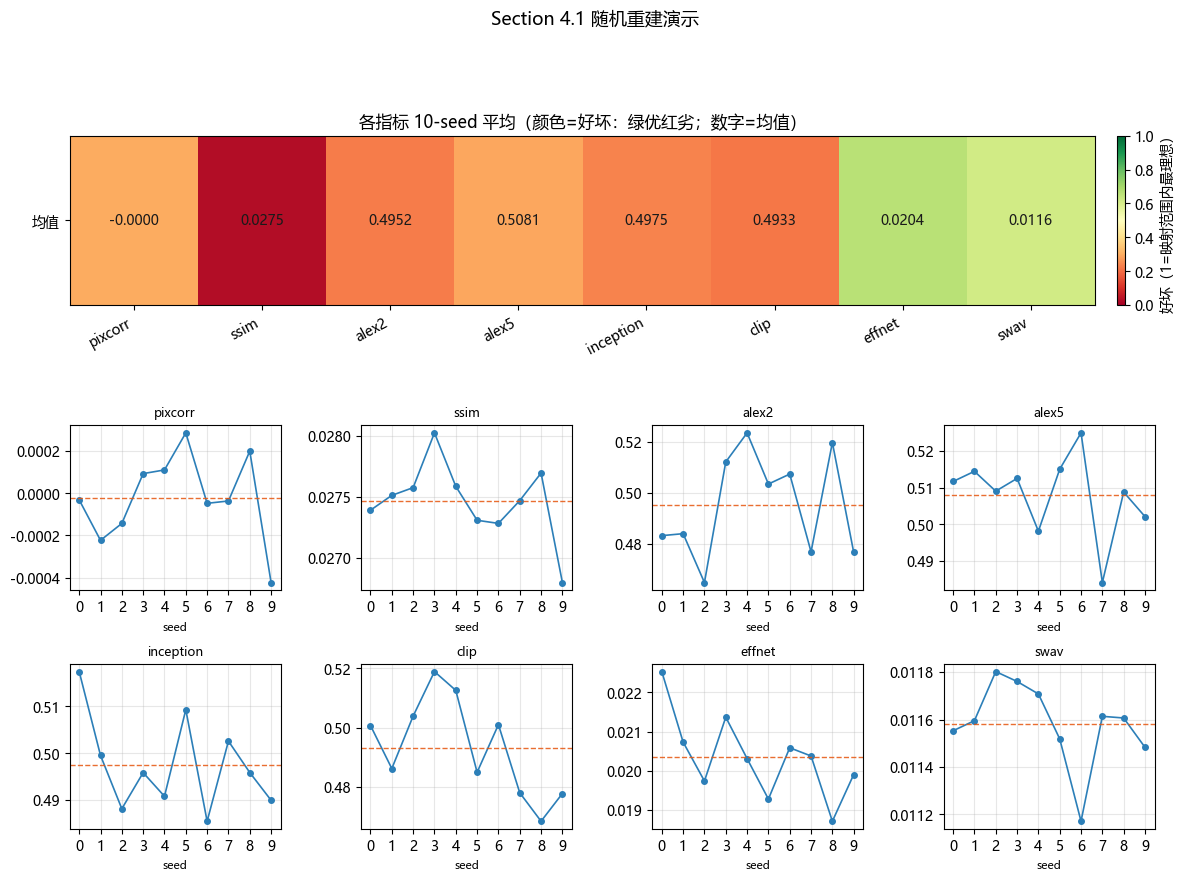

In [15]:
# 4.1 评测结果可视化（依赖 reconstruction_results / reconstruction_summary）
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec

try:
    reconstruction_results
    reconstruction_summary
except NameError as e:
    raise RuntimeError("请先运行 4.1 中「10 seeds 随机重建评测」那一格。") from e

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

METRIC_KEYS = list(reconstruction_results[0].keys())
SEEDS = list(range(len(reconstruction_results)))
M = np.array([[reconstruction_results[s][k] for s in SEEDS] for k in METRIC_KEYS], dtype=np.float64)
means = M.mean(axis=1)

# 好坏映射：higher=值越大越好；lower=值越小越好（如距离类指标）
METRIC_GOODNESS_RANGE = {
    "eval_pixcorr": ("higher", -0.15, 0.35),
    "eval_ssim": ("higher", 0.0, 1.0),
    "eval_alex2": ("higher", 0.45, 0.65),
    "eval_alex5": ("higher", 0.45, 0.65),
    "eval_inception": ("higher", 0.45, 0.65),
    "eval_clip": ("higher", 0.45, 0.65),
    "eval_effnet": ("lower", 0.0, 0.06),
    "eval_swav": ("lower", 0.0, 0.03),
}


def value_to_goodness(key: str, v: float) -> float:
    spec = METRIC_GOODNESS_RANGE.get(key)
    if spec is None:
        return float(np.clip(v, 0.0, 1.0))
    direction, lo, hi = spec
    if hi <= lo:
        return 0.5
    if direction == "higher":
        g = (v - lo) / (hi - lo)
    else:
        g = (hi - v) / (hi - lo)
    return float(np.clip(g, 0.0, 1.0))


G = np.array([value_to_goodness(k, means[i]) for i, k in enumerate(METRIC_KEYS)], dtype=np.float64).reshape(1, -1)

fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[0.42, 1.0], hspace=0.42)

ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(G, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax0.set_xticks(np.arange(len(METRIC_KEYS)))
ax0.set_xticklabels([k.replace("eval_", "") for k in METRIC_KEYS], rotation=28, ha="right", fontsize=10)
ax0.set_yticks([0])
ax0.set_yticklabels(["均值"])
ax0.set_title("各指标 10-seed 平均（颜色=好坏：绿优红劣；数字=均值）")
cb = fig.colorbar(im, ax=ax0, fraction=0.035, pad=0.02)
cb.set_label("好坏（1=映射范围内最理想）")

for j in range(len(METRIC_KEYS)):
    ax0.text(j, 0, f"{means[j]:.4f}", ha="center", va="center", fontsize=10, color="0.1")

gs_sub = GridSpecFromSubplotSpec(2, 4, subplot_spec=gs[1], hspace=0.45, wspace=0.38)
for idx, k in enumerate(METRIC_KEYS):
    ax = fig.add_subplot(gs_sub[idx // 4, idx % 4])
    ax.plot(SEEDS, M[idx], "-o", markersize=4, linewidth=1.2, color="#2c7fb8")
    ax.axhline(means[idx], color="#e6550d", ls="--", lw=1.0, alpha=0.85)
    ax.set_xticks(SEEDS)
    ax.set_xlabel("seed", fontsize=8)
    ax.set_title(k.replace("eval_", ""), fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Section 4.1 随机重建演示", fontsize=13, y=1.02)
plt.show()


## 6. 端到端模型训练 Pipeline（仅 Task 2：图像重建）

以下代码实现从 **EEG 信号到图像** 的条件扩散重建系统。本笔记**已省略 Task 1（EEG–CLIP 检索）**；请从 **6.6** 起按顺序运行。

### 架构概览
- **Task 2（重建）**：EEG 多尺度 CNN + Transformer 骨干 → EEG Projector 输出 Context Embedding → **LoRA** 微调 Stable Diffusion UNet 的 Cross-Attention → **Classifier-Free Guidance** 采样

### 训练策略要点
1. **两阶段 Curriculum**：先在 `avg_trials=False` 的扩充数据上预训练，再在 `avg_trials=True` 的干净数据上微调
2. **数据增强**（EEG）：Channel Masking、Temporal Shift、Gaussian Noise（见 6.8 数据集）
3. **Classifier-Free Guidance**：训练时约 10% 概率 drop EEG 条件；推理时用 CFG scale 提升条件强度


### 6.0 环境准备与图像解压

In [16]:
import os, shutil, zipfile
from pathlib import Path

os.environ["HF_HOME"] = r"D:\AI_Cache\huggingface"
os.environ["TORCH_HOME"] = r"D:\AI_Cache\torch"

DATA_DIR = Path("image-eeg-data")

# ── 训练图像：zip 内顶层是 training_images/，train.pt 里写的是 train_images/...
#    优先尝试把文件夹改名为 train_images；Windows 上常因资源管理器/杀毒占用导致 rename 失败，
#    此时可忽略：后面 EEGImageDataset 会自动映射到 training_images/。
train_zip = DATA_DIR / "training_images.zip"
if train_zip.is_file():
    if not (DATA_DIR / "train_images").is_dir():
        print("正在解压 training_images.zip ...")
        with zipfile.ZipFile(train_zip, "r") as zf:
            zf.extractall(DATA_DIR)
        print("  -> 解压完成")
    ti, tr = DATA_DIR / "training_images", DATA_DIR / "train_images"
    if ti.is_dir() and not tr.is_dir():
        try:
            shutil.move(str(ti), str(tr))
            print("  -> 已将 training_images 重命名为 train_images（与 train.pt 一致）")
        except (PermissionError, OSError) as e:
            print(f"  -> 跳过重命名（权限/占用）: {e}")
            print("     不影响训练：6.8 的 EEGImageDataset 会自动使用 training_images/ 路径。")
    elif tr.is_dir():
        print("  -> train_images 目录已就绪")
else:
    print("  [警告] 未找到 training_images.zip，请确认数据目录完整")

# ── 测试图像：zip 内为 test_images/，与 test.pt 一致 ──
test_zip = DATA_DIR / "test_images.zip"
if test_zip.is_file():
    if not (DATA_DIR / "test_images").is_dir():
        print("正在解压 test_images.zip ...")
        with zipfile.ZipFile(test_zip, "r") as zf:
            zf.extractall(DATA_DIR)
        print("  -> test_images 解压完成")
    else:
        print("  -> test_images 已存在，跳过解压")
else:
    print("  [警告] 未找到 test_images.zip")

print("图像数据就绪。")

  -> train_images 目录已就绪
  -> test_images 已存在，跳过解压
图像数据就绪。


### 6.6 Task 2 模型定义：EEG Projector + LoRA Stable Diffusion

**架构说明**：

1. **EEG Projector**：在 **CNN+Transformer 骨干**（与下方 `EEGBackbone` 一致）之上接多层 Projector，将 EEG 编码为 `[B, num_tokens, 768]` 的 Context 序列，供 SD 1.5 UNet Cross-Attention 使用。
   `num_tokens` 取 77（与 CLIP 文本长度一致），便于用 EEG 条件替代文本条件。

2. **Stable Diffusion LoRA**：冻结 VAE 与 UNet 主干，仅在 UNet Cross-Attention 的线性层注入 LoRA（**rank=8**），参数量小、可训练。

3. **Classifier-Free Guidance (CFG)**：训练时随机将 EEG Context 置零（unconditional）；推理时用 `cfg_scale` 放大条件信号。

4. **多尺度 token**：77 个 query token 通过 Cross-Attention 从 EEG 序列特征中读出，供 UNet 各层使用。


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ══════════════════════════════════════════════════════════════
# EEG 特征提取骨干（与 Projector、LoRA 端到端联合训练）
# Task 2 需要一个 CNN+Transformer 骨干把 EEG [B,63,250] 编码为序列特征，
# 然后由 Projector 转化为 SD 的 context embedding。
# 骨干的参数会和 Projector + LoRA 一起端到端训练。
# ══════════════════════════════════════════════════════════════

class MultiScaleCNN1D(nn.Module):
    """
    多尺度并行 1D 卷积前端。
    不同 kernel size 分别捕获：
      - k=3: 高频局部模式 (~12ms @ 250Hz)
      - k=7: 中频节律 (~28ms, α/β 波段)
      - k=15: 低频慢波 (~60ms, θ/δ 波段)
    """

    def __init__(self, in_channels: int = 63, hidden_dim: int = 256):
        super().__init__()
        branch_dim = hidden_dim // 3

        self.branch_short = nn.Sequential(
            nn.Conv1d(in_channels, branch_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.Conv1d(branch_dim, branch_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
        )
        self.branch_mid = nn.Sequential(
            nn.Conv1d(in_channels, branch_dim, kernel_size=7, padding=3),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.Conv1d(branch_dim, branch_dim, kernel_size=7, padding=3),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
        )
        self.branch_long = nn.Sequential(
            nn.Conv1d(in_channels, branch_dim, kernel_size=15, padding=7),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.Conv1d(branch_dim, branch_dim, kernel_size=15, padding=7),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
        )
        self.fuse = nn.Sequential(
            nn.Conv1d(branch_dim * 3, hidden_dim, kernel_size=1),
            nn.BatchNorm1d(hidden_dim), nn.GELU(),
        )

    def forward(self, x):
        return self.fuse(torch.cat([
            self.branch_short(x), self.branch_mid(x), self.branch_long(x),
        ], dim=1))


class EEGBackbone(nn.Module):
    """
    EEG 序列特征提取器：CNN → 下采样 → Transformer → 全序列输出。
    输出 [B, seq_len, tf_dim] 供 Projector 使用。
    """

    def __init__(self, in_channels=63, cnn_dim=256, tf_dim=256,
                 tf_heads=8, tf_layers=4, tf_dropout=0.1):
        super().__init__()
        self.cnn = MultiScaleCNN1D(in_channels, cnn_dim)
        self.downsample = nn.Sequential(
            nn.Conv1d(cnn_dim, tf_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(tf_dim), nn.GELU(),
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, tf_dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, 126 + 1, tf_dim) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=tf_dim, nhead=tf_heads, dim_feedforward=tf_dim * 4,
            dropout=tf_dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=tf_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: [B, 63, 250] -> [B, 126, tf_dim]"""
        h = self.cnn(x)
        h = self.downsample(h)
        h = h.transpose(1, 2)  # [B, ~125, tf_dim]

        B = h.shape[0]
        cls = self.cls_token.expand(B, -1, -1)
        h = torch.cat([cls, h], dim=1)
        seq_len = h.shape[1]
        h = h + self.pos_embed[:, :seq_len, :]
        h = self.transformer(h)
        return h  # [B, 126, tf_dim]


# ══════════════════════════════════════════════════════════════
# EEG Projector：骨干序列特征 → SD Cross-Attention Context
# ══════════════════════════════════════════════════════════════

class EEGProjectorTask2(nn.Module):
    """
    EEG -> [B, 77, 768] Context Embedding，供 SD UNet Cross-Attention 使用。

    77 tokens 与 SD1.5 CLIP text encoder 输出长度一致，
    LoRA 无需适应不同的注意力矩阵尺寸。

    参数 freeze_backbone 控制骨干是否冻结：
      - True: 骨干权重固定，只训练 Projector + LoRA（适用于骨干已预训练的场景）
      - False: 骨干与 Projector 端到端联合训练（本笔记默认）
    """

    def __init__(
        self,
        backbone: nn.Module,
        tf_dim: int = 256,
        sd_context_dim: int = 768,
        num_context_tokens: int = 77,
        freeze_backbone: bool = False,
    ):
        super().__init__()
        self.backbone = backbone
        self.freeze_backbone = freeze_backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad_(False)

        self.query_tokens = nn.Parameter(
            torch.randn(1, num_context_tokens, sd_context_dim) * 0.02
        )
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=sd_context_dim, num_heads=8,
            kdim=tf_dim, vdim=tf_dim, batch_first=True, dropout=0.1,
        )
        self.ln_q = nn.LayerNorm(sd_context_dim)
        self.ln_kv = nn.LayerNorm(tf_dim)

        self.ffn = nn.Sequential(
            nn.LayerNorm(sd_context_dim),
            nn.Linear(sd_context_dim, sd_context_dim * 4), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(sd_context_dim * 4, sd_context_dim), nn.Dropout(0.1),
        )
        self.final_ln = nn.LayerNorm(sd_context_dim)

    def forward(self, eeg: torch.Tensor) -> torch.Tensor:
        """eeg: [B, 63, 250] -> [B, 77, 768]"""
        if self.freeze_backbone:
            with torch.no_grad():
                seq_feat = self.backbone(eeg)
        else:
            seq_feat = self.backbone(eeg)

        B = seq_feat.shape[0]
        queries = self.query_tokens.expand(B, -1, -1)

        q = self.ln_q(queries)
        kv = self.ln_kv(seq_feat)
        ctx, _ = self.cross_attn(q, kv, kv)
        ctx = ctx + queries

        ctx = ctx + self.ffn(ctx)
        ctx = self.final_ln(ctx)
        return ctx


# ── 快速验证 ──
_backbone_test = EEGBackbone()
_proj_test = EEGProjectorTask2(_backbone_test, freeze_backbone=False)
_total_params = sum(p.numel() for p in _proj_test.parameters() if p.requires_grad)
print(f"EEGBackbone + Projector 总可训练参数: {_total_params / 1e6:.2f}M")
_test_ctx = _proj_test(torch.randn(2, 63, 250))
print(f"Context 输出 shape: {_test_ctx.shape}")  # 期望 [2, 77, 768]
del _backbone_test, _proj_test, _test_ctx


EEGBackbone + Projector 总可训练参数: 10.13M
Context 输出 shape: torch.Size([2, 77, 768])


d:\Anaconda\envs\torch_gpu\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


### 6.7 加载 Stable Diffusion 并注入 LoRA

加载 SD 1.5 预训练模型，冻结 VAE 和 UNet 全部骨干参数，然后用 `peft` 在 UNet 的 Cross-Attention 层注入 rank=8 的 LoRA 适配器。


In [18]:
import torch
from diffusers import DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from peft import LoraConfig, get_peft_model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 使用 HF 上常用的官方仓库 ID（错误 ID 会导致 from_pretrained 下载失败）
SD_MODEL_ID = "runwayml/stable-diffusion-v1-5"

# ── 1. 加载 SD 1.5 各组件 ──
print("加载 Stable Diffusion 1.5 ...")
noise_scheduler = DDPMScheduler.from_pretrained(SD_MODEL_ID, subfolder="scheduler")
vae = AutoencoderKL.from_pretrained(SD_MODEL_ID, subfolder="vae").to(DEVICE)
unet = UNet2DConditionModel.from_pretrained(SD_MODEL_ID, subfolder="unet").to(DEVICE)

# ── 2. 完全冻结 VAE 和 UNet ──
vae.eval()
vae.requires_grad_(False)
unet.requires_grad_(False)

# ── 3. 在 UNet Cross-Attention 层注入 LoRA ──
# target_modules 精确匹配 UNet 中所有 cross-attention 的 to_k, to_v, to_q, to_out 线性层
# rank=8 / alpha=8 在 8GB 级显存上仍较稳妥，表达能力更强
lora_config = LoraConfig(
    r=8,
    lora_alpha=8,
    target_modules=[
        "to_k", "to_v", "to_q", "to_out.0",
    ],
    lora_dropout=0.05,
    bias="none",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

# ── 4. 统计 ──
total_params = sum(p.numel() for p in unet.parameters())
trainable_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f"UNet 总参数: {total_params / 1e6:.1f}M, LoRA 可训练: {trainable_params / 1e6:.2f}M")
print(f"VAE 参数: {sum(p.numel() for p in vae.parameters()) / 1e6:.1f}M (全部冻结)")


Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "d:\Anaconda\envs\torch_gpu\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "d:\Anaconda\envs\torch_gpu\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "d:\Anaconda\envs\torch_gpu\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "d:\Anaconda\envs\torch_gpu\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb2 in position 7: invalid start byte


加载 Stable Diffusion 1.5 ...
trainable params: 1,594,368 || all params: 861,115,332 || trainable%: 0.1852
UNet 总参数: 861.1M, LoRA 可训练: 1.59M
VAE 参数: 83.7M (全部冻结)


### 6.8 Task 2 训练数据集

Task 2 需要 EEG 信号 + 对应的真实图像（用于 VAE 编码为 latent 作为去噪目标）。

In [21]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from pathlib import Path
from PIL import Image
import numpy as np

# 与 6.0 中定义一致；若单独从本 cell 开始跑 Task2，必须先有 DATA_DIR，否则会 NameError
DATA_DIR = Path("image-eeg-data")


class EEGImageDataset(Dataset):
    """
    Task 2 用：返回 (EEG, 图像张量) 对。
    图像会被 resize 到 384 x 384 并归一化到 [-1, 1]（SD VAE 输入规范）。
    """

    def __init__(
        self,
        pt_path: str,
        data_dir: str,
        avg_trials: bool = True,
        augment_eeg: bool = False,
        image_size: int = 384,
    ):
        raw = torch.load(pt_path, weights_only=False)
        eeg = torch.as_tensor(raw["eeg"]).float()
        imgs = np.array(raw["img"])

        if eeg.ndim == 4:
            if avg_trials:
                eeg = eeg.mean(dim=1)
                if imgs.ndim == 2:
                    imgs = imgs[:, 0]
            else:
                N, T_trial, C, T_time = eeg.shape
                eeg = eeg.reshape(N * T_trial, C, T_time)
                imgs = imgs.reshape(-1)

        self.eeg = eeg
        self.data_dir = Path(data_dir)
        # train.pt 里路径为 train_images/...，但 zip 解压后目录常为 training_images/...
        self.img_paths = []
        for p in imgs.tolist():
            rel = str(p).replace("\\", "/")
            cand = self.data_dir / rel
            if cand.is_file():
                self.img_paths.append(cand)
            elif rel.startswith("train_images/"):
                alt = self.data_dir / rel.replace("train_images/", "training_images/", 1)
                self.img_paths.append(alt if alt.is_file() else cand)
            else:
                self.img_paths.append(cand)
        self.augment_eeg = augment_eeg

        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # -> [-1, 1]
        ])

    def __len__(self):
        return len(self.eeg)

    def _augment_eeg(self, x):
        C, T = x.shape
        if torch.rand(1).item() < 0.5:
            mask = torch.rand(C) > 0.15
            x = x * mask.unsqueeze(1).float()
        if torch.rand(1).item() < 0.5:
            shift = torch.randint(-15, 16, (1,)).item()
            x = torch.roll(x, shifts=shift, dims=1)
        if torch.rand(1).item() < 0.5:
            x = x + torch.randn_like(x) * 0.02
        return x

    def __getitem__(self, idx):
        eeg = self.eeg[idx].clone()
        if self.augment_eeg:
            eeg = self._augment_eeg(eeg)
        img = Image.open(self.img_paths[idx]).convert("RGB")
        img = self.img_transform(img)
        return eeg, img


# ── 构建 Task2 数据集 ──
# 阶段1：带噪大数据
train_ds_t2_noisy = EEGImageDataset(
    DATA_DIR / "train.pt", DATA_DIR,
    avg_trials=False, augment_eeg=True,
)
# 阶段2：干净数据
train_ds_t2_clean = EEGImageDataset(
    DATA_DIR / "train.pt", DATA_DIR,
    avg_trials=True, augment_eeg=True,
)

print(f"Task2 阶段1数据: {len(train_ds_t2_noisy)} 样本")
print(f"Task2 阶段2数据: {len(train_ds_t2_clean)} 样本")
_e, _i = train_ds_t2_clean[0]
print(f"EEG shape: {_e.shape}, Image shape: {_i.shape}, Image range: [{_i.min():.1f}, {_i.max():.1f}]")
del _e, _i

Task2 阶段1数据: 66160 样本
Task2 阶段2数据: 16540 样本
EEG shape: torch.Size([63, 250]), Image shape: torch.Size([3, 384, 384]), Image range: [-0.9, 1.0]


### 6.9 Task 2 训练 Loop

训练目标：给定 EEG 信号，让 LoRA-UNet 学会在 EEG Context 引导下对图像 latent 去噪。

关键设计：
- **Diffusion Loss**：标准的 ε-prediction MSE loss
- **CFG 训练**：10% 概率随机 drop EEG 条件（替换为零向量），让模型同时学会有条件和无条件去噪
- **显存优化**：使用 gradient checkpointing + mixed precision (fp16)

In [ ]:
# 6.9 Task 2 训练：ε-prediction + CFG dropout + AMP + gradient checkpointing
import sys
import gc
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_T2_NUM_WORKERS = 0 if sys.platform == "win32" else 4
_USE_AMP = DEVICE.type == "cuda"

CFG_DROP_PROB = 0.10

T2_S1_EPOCHS = 5
T2_S2_EPOCHS = 20
T2_BATCH_S1 = 1
T2_BATCH_S2 = 1
T2_LR = 2e-4
T2_LORA_LR = 5e-5
T2_WEIGHT_DECAY = 0.01
T2_MAX_BATCHES_PER_EPOCH_S1 = None
T2_MAX_BATCHES_PER_EPOCH_S2 = None


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

eeg_backbone = EEGBackbone(in_channels=63, cnn_dim=256, tf_dim=256, tf_heads=8, tf_layers=4).to(DEVICE)

projector = EEGProjectorTask2(
    eeg_backbone, tf_dim=256, sd_context_dim=768, num_context_tokens=77, freeze_backbone=False
).to(DEVICE)

unet.enable_gradient_checkpointing()
vae.eval()
vae.requires_grad_(False)

params_p = list(projector.parameters())
params_lora = [p for p in unet.parameters() if p.requires_grad]
optimizer = AdamW(
    [
        {"params": params_p, "lr": T2_LR, "weight_decay": T2_WEIGHT_DECAY},
        {"params": params_lora, "lr": T2_LORA_LR, "weight_decay": T2_WEIGHT_DECAY},
    ]
)
scaler = torch.amp.GradScaler("cuda", enabled=_USE_AMP)


def train_task2_one_epoch(loader, max_batches=None) -> float:
    projector.train()
    unet.train()
    vae.eval()
    running = 0.0
    n = 0
    pbar = tqdm(loader, leave=True)
    for step, (eeg, pixel_values) in enumerate(pbar):
        if max_batches is not None and step >= max_batches:
            break
        eeg = eeg.to(DEVICE, non_blocking=True)
        pixel_values = pixel_values.to(DEVICE, non_blocking=True)
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],),
            device=DEVICE,
            dtype=torch.long,
        )
        noisy = noise_scheduler.add_noise(latents, noise, timesteps)

        ctx = projector(eeg)
        if torch.rand(1, device=DEVICE).item() < CFG_DROP_PROB:
            ctx = torch.zeros_like(ctx)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", dtype=torch.float16, enabled=_USE_AMP):
            pred = unet(noisy, timesteps, encoder_hidden_states=ctx).sample
            loss = F.mse_loss(pred.float(), noise.float())

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(projector.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(params_lora, 1.0)
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        n += 1
        pbar.set_postfix(loss=f"{running/n:.4f}")

    return running / max(n, 1)


loader_s1 = DataLoader(
    train_ds_t2_noisy,
    batch_size=T2_BATCH_S1,
    shuffle=True,
    num_workers=_T2_NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)
loader_s2 = DataLoader(
    train_ds_t2_clean,
    batch_size=T2_BATCH_S2,
    shuffle=True,
    num_workers=_T2_NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

sched1 = CosineAnnealingLR(optimizer, T_max=max(T2_S1_EPOCHS, 1))
print("=== Task2 阶段1 (noisy) ===")
for ep in range(T2_S1_EPOCHS):
    loss = train_task2_one_epoch(loader_s1, T2_MAX_BATCHES_PER_EPOCH_S1)
    sched1.step()
    print(f"  epoch {ep+1}/{T2_S1_EPOCHS}  loss={loss:.5f}")

optimizer.param_groups[0]["lr"] = T2_LR
optimizer.param_groups[1]["lr"] = T2_LORA_LR
sched2 = CosineAnnealingLR(optimizer, T_max=max(T2_S2_EPOCHS, 1))

print("=== Task2 阶段2 (clean) ===")
for ep in range(T2_S2_EPOCHS):
    loss = train_task2_one_epoch(loader_s2, T2_MAX_BATCHES_PER_EPOCH_S2)
    sched2.step()
    print(f"  epoch {ep+1}/{T2_S2_EPOCHS}  loss={loss:.5f}")

torch.save(projector.state_dict(), "task2_projector_final.pt")
unet.save_pretrained("task2_unet_lora_final")
print("已保存 task2_projector_final.pt 与 task2_unet_lora_final/")
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


### 6.10 Task 2 推理：Classifier-Free Guidance 采样

推理时用 DDPM/DDIM 采样，通过 CFG scale 放大 EEG 条件的引导效果：

$$\epsilon_{\text{guided}} = \epsilon_{\text{uncond}} + s \cdot (\epsilon_{\text{cond}} - \epsilon_{\text{uncond}})$$

其中 $s$ 是 CFG scale（典型值 3.0~7.5）。$s$ 越大，生成图像越忠于 EEG 语义但多样性降低。

In [ ]:
import torch
from diffusers import DDIMScheduler
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@torch.inference_mode()
def generate_images_from_eeg(
    eeg_batch: torch.Tensor,
    projector: torch.nn.Module,
    unet: torch.nn.Module,
    vae,
    cfg_scale: float = 6.0,
    num_inference_steps: int = 50,
    image_size: int = 384,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    """
    从 EEG 信号生成图像。

    显存优化：CFG 改为「无条件 / 条件」两次各 B 的 UNet 前向，避免原版一次 2B batch 爆显存。
    推理使用 fp16 autocast（仅 CUDA）。VAE 解码启用 slicing。
    """
    projector.eval()
    unet.eval()
    vae.eval()

    if hasattr(unet, "enable_attention_slicing"):
        try:
            unet.enable_attention_slicing()
        except Exception:
            pass
    if hasattr(vae, "enable_slicing"):
        try:
            vae.enable_slicing()
        except Exception:
            pass

    _use_amp = device.type == "cuda"

    B = eeg_batch.shape[0]
    eeg_batch = eeg_batch.to(device)
    print(
        f"[Task2 gen] B={B}, size={image_size}, DDIM={num_inference_steps}, amp={_use_amp} — CFG=顺序双次前向(省显存)",
        flush=True,
    )

    eeg_context = projector(eeg_batch)
    uncond_context = torch.zeros_like(eeg_context)

    latent_size = image_size // 8
    latents = torch.randn(B, 4, latent_size, latent_size, device=device)

    ddim_scheduler = DDIMScheduler.from_config(noise_scheduler.config)
    ddim_scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = ddim_scheduler.timesteps

    pbar = tqdm(
        enumerate(timesteps),
        total=len(timesteps),
        desc="DDIM Sampling",
        leave=True,
        mininterval=0.3,
    )
    for si, t in pbar:
        t_b = t.expand(B).long()
        # 顺序 CFG：峰值显存约为「单次 B」而非「单次 2B」
        with torch.amp.autocast("cuda", dtype=torch.float16, enabled=_use_amp):
            eps_u = unet(latents, t_b, encoder_hidden_states=uncond_context).sample
        with torch.amp.autocast("cuda", dtype=torch.float16, enabled=_use_amp):
            eps_c = unet(latents, t_b, encoder_hidden_states=eeg_context).sample
        noise_pred = eps_u.float() + cfg_scale * (eps_c.float() - eps_u.float())
        del eps_u, eps_c

        latents = ddim_scheduler.step(noise_pred, t, latents).prev_sample

        if si == 0 and device.type == "cuda":
            torch.cuda.synchronize()
            print("  → 第 1 步完成（顺序 CFG 已用两次小前向代替一次 2B 前向）", flush=True)

    latents = latents / vae.config.scaling_factor
    with torch.amp.autocast("cuda", dtype=torch.float16, enabled=_use_amp):
        images = vae.decode(latents).sample
    images = (images.float() / 2 + 0.5).clamp(0, 1)

    if device.type == "cuda":
        torch.cuda.empty_cache()

    return images


print("推理函数定义完毕（顺序 CFG + fp16 + VAE slicing）。")



推理函数定义完毕（顺序 CFG + fp16 + VAE slicing）。


### 6.11 Task 2 正式评测（10 seeds 报告）

对 200 张测试图片，用训练好的模型生成重建图像，然后调用 Section 4 定义的 `eval_images(...)` 官方评测函数。
每个 seed 独立采样并评测，最终汇报 mean ± std。

**完全体默认**：DDIM **50** 步、生成 **512×512**（再插值到评测 256）、CFG **6.0**；若显存不足，将代码中 `GEN_IMAGE_SIZE`/`NUM_DDIM_STEPS` 降为 384/25。


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from pathlib import Path
from PIL import Image
import numpy as np
import random
import io
from contextlib import redirect_stdout
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("image-eeg-data")

try:
    eval_images
except NameError as _e:
    raise RuntimeError(
        "未定义 eval_images：请先运行笔记本「## 4. Reconstruction Evaluation」里定义 eval_images 的代码单元，再运行 6.11。"
    ) from _e


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def summarize_metrics_over_seeds(metric_list):
    keys = metric_list[0].keys()
    summary = {}
    for key in keys:
        values = np.array([m[key] for m in metric_list], dtype=np.float64)
        summary[key] = {
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
        }
    return summary


def load_test_real_images(image_size: int = 256) -> torch.Tensor:
    raw = torch.load(DATA_DIR / "test.pt", weights_only=False)
    imgs = np.array(raw["img"])
    if imgs.ndim == 2:
        imgs = imgs[:, 0]

    transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ]
    )

    images = []
    for p in imgs.tolist():
        img = Image.open(DATA_DIR / p).convert("RGB")
        images.append(transform(img))

    return torch.stack(images)


def generate_all_test_reconstructions(
    projector,
    unet,
    vae,
    cfg_scale: float = 6.0,
    num_inference_steps: int = 25,
    gen_image_size: int = 384,
    eval_image_size: int = 256,
    gen_batch_size: int = 1,
    num_samples: int = 200,
) -> torch.Tensor:
    raw = torch.load(DATA_DIR / "test.pt", weights_only=False)
    eeg = torch.as_tensor(raw["eeg"]).float()
    eeg = eeg[:num_samples]
    if eeg.ndim == 4:
        eeg = eeg.mean(dim=1)

    all_recons = []
    with tqdm(total=len(eeg), desc="Overall Gen Progress", unit="img", colour="green") as pbar:
        for i in range(0, len(eeg), gen_batch_size):
            batch_eeg = eeg[i : i + gen_batch_size]
            trap = io.StringIO()
            with redirect_stdout(trap):
                recon = generate_images_from_eeg(
                    batch_eeg,
                    projector,
                    unet,
                    vae,
                    cfg_scale=cfg_scale,
                    num_inference_steps=num_inference_steps,
                    image_size=gen_image_size,
                )
            if gen_image_size != eval_image_size:
                recon = torch.nn.functional.interpolate(
                    recon,
                    size=(eval_image_size, eval_image_size),
                    mode="bilinear",
                    align_corners=False,
                )
            all_recons.append(recon.cpu())
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            pbar.update(len(batch_eeg))

    return torch.cat(all_recons)


# ========== 正式评测（默认：200 张全测试集、50 步 DDIM、512 生成、10 seeds）==========
NUM_DDIM_STEPS = 50
NUM_SEEDS = 1
GEN_BATCH_SIZE = 1
GEN_IMAGE_SIZE = 384
NUM_TEST_SAMPLES = 200
CFG_EVAL = 6.0

print(f"正在加载前 {NUM_TEST_SAMPLES} 张测试集真实图像 ...")
real_images = load_test_real_images(image_size=256)[:NUM_TEST_SAMPLES]
print(f"真实图像 shape: {real_images.shape}")

reconstruction_results_real = []
for seed in range(NUM_SEEDS):
    print(f"\n--- 评测 Seed {seed} ---")
    set_seed(seed)

    fake_images = generate_all_test_reconstructions(
        projector,
        unet,
        vae,
        cfg_scale=CFG_EVAL,
        num_inference_steps=NUM_DDIM_STEPS,
        gen_image_size=GEN_IMAGE_SIZE,
        eval_image_size=256,
        gen_batch_size=GEN_BATCH_SIZE,
        num_samples=NUM_TEST_SAMPLES,
    )
    print(f"\n重建图像 shape: {fake_images.shape}")

    metrics = eval_images(
        real_images=real_images,
        fake_images=fake_images,
        device=DEVICE,
    )
    reconstruction_results_real.append(metrics)
    print(f"Seed {seed} 评测结果: {metrics}")

recon_summary = summarize_metrics_over_seeds(reconstruction_results_real)
print("\n" + "=" * 60)
print("Task 2: 图像重建评测（mean ± std）")
print("=" * 60)
print("\nPer-seed:")
for seed, m in enumerate(reconstruction_results_real):
    items = " | ".join(f"{k}={v:.4f}" for k, v in m.items())
    print(f"  seed={seed:02d} | {items}")

print("\nSummary (mean ± std):")
for key, stats in recon_summary.items():
    print(f"  {key}: {stats['mean']:.4f} ± {stats['std']:.4f}")


### 6.12 重建评测结果：指标含义与可视化

`eval_images(real_images, fake_images)` 会在 **每一张真实图** 与 **同索引的重建图** 之间算相似度，再对 200 张（或你的子集）做平均，得到一组标量。

| 键名 | 通俗含义 | 好坏方向（越高/越低） |
|------|----------|------------------------|
| `eval_pixcorr` | 把图拉成一长串像素后，**逐张算**「真实 vs 重建」的**皮尔逊相关系数**再平均 | 越接近 **1** 越好（完全无关约 0，随机独立也可能接近 0） |
| `eval_ssim` | **结构相似度**（亮度/对比度/结构），经典图像质量指标 | **越大越好**，最大 1 |
| `eval_alex2` / `eval_alex5` | 用 **AlexNet** 浅层/深层特征做「**二选一鉴别**」：重建图更像自己的真实图，还是更像别人的？ | 随机约 **0.5**；**明显高于 0.5** 说明语义/纹理对齐更好 |
| `eval_inception` | 同上思路，特征来自 **Inception v3** | 随机约 **0.5**，越高越好 |
| `eval_clip` | 在 **CLIP 视觉编码器** 的特征空间里做同样鉴别 | 随机约 **0.5**，越高越好（偏语义） |
| `eval_effnet` | **EfficientNet** 特征向量上的 **相关距离**（与「越相似距离越小」一致，实现里是 correlation 型度量） | 依实现：**越小通常表示特征越接近**（以你跑出的数量级为准，和随机基线对比） |
| `eval_swav` | **SwAV 自监督 ResNet50** 特征上的相关距离 | 同上，与基线对比 |

下面代码：**柱状图**扫一眼各指标；若你已跑过 6.11 且内存里还有 `real_images` / `fake_images`，会再画 **真实 | 重建** 对照图。


In [ ]:
# 若无可视化库：pip install matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# —— 中文显示（Windows 常见黑体 / 微软雅黑）——
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

METRIC_LABELS = {
    "eval_pixcorr": "像素相关\n(越接近1越好)",
    "eval_ssim": "SSIM 结构相似\n(越大越好,≤1)",
    "eval_alex2": "Alex 浅层鉴别\n(随机~0.5,越高越好)",
    "eval_alex5": "Alex 深层鉴别\n(随机~0.5)",
    "eval_inception": "Inception 鉴别\n(随机~0.5)",
    "eval_clip": "CLIP 语义鉴别\n(随机~0.5)",
    "eval_effnet": "EffNet 特征距离\n(越小越接近,看相对基线)",
    "eval_swav": "SwAV 特征距离\n(越小越接近,看相对基线)",
}


def plot_metrics_bar(metrics: dict, title: str = "eval_images 各指标一览") -> None:
    keys = [k for k in METRIC_LABELS if k in metrics]
    vals = [float(metrics[k]) for k in keys]
    labels = [METRIC_LABELS[k].replace(chr(10), " ") for k in keys]
    colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(keys)))

    fig, ax = plt.subplots(figsize=(10, max(4, len(keys) * 0.35)))
    y = np.arange(len(keys))
    ax.barh(y, vals, color=colors, height=0.65)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("指标数值（含义见表）")
    ax.set_title(title)
    for yi, v in zip(y, vals):
        ax.text(v, yi, f"  {v:.4f}", va="center", fontsize=8)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_real_vs_fake_grid(
    real: torch.Tensor,
    fake: torch.Tensor,
    n_show: int = 6,
    seed_start: int = 0,
) -> None:
    # real / fake: [N,3,H,W] 值域约 [0,1]
    n_show = min(n_show, real.shape[0], fake.shape[0])
    real = real[:n_show].detach().cpu().float().clamp(0, 1)
    fake = fake[:n_show].detach().cpu().float().clamp(0, 1)

    fig, axes = plt.subplots(n_show, 2, figsize=(6, 2.2 * n_show))
    if n_show == 1:
        axes = np.array([axes])
    for i in range(n_show):
        axes[i, 0].imshow(real[i].permute(1, 2, 0).numpy())
        axes[i, 0].set_title(f"真实 #{seed_start + i}")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(fake[i].permute(1, 2, 0).numpy())
        axes[i, 1].set_title(f"重建 #{seed_start + i}")
        axes[i, 1].axis("off")
    plt.suptitle("左：测试集真实图  |  右：模型重建（同索引对比）", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


# ========== 1) 优先用你 6.11 跑完的字典；否则用演示数字 ==========
if "reconstruction_results_real" in globals() and len(reconstruction_results_real) > 0:
    _m = reconstruction_results_real[-1]
    print("使用：reconstruction_results_real 中最后一次 seed 的指标")
elif "metrics" in globals() and isinstance(metrics, dict) and "eval_ssim" in metrics:
    _m = metrics
    print("使用：当前变量 metrics")
else:
    _m = {
        "eval_pixcorr": 0.01,
        "eval_ssim": 0.24,
        "eval_alex2": 0.48,
        "eval_alex5": 0.47,
        "eval_inception": 0.48,
        "eval_clip": 0.53,
        "eval_effnet": 0.02,
        "eval_swav": 0.01,
    }
    print("演示模式：未找到 reconstruction_results_real，使用示例数值（请跑完 6.11 后重跑本格）")

plot_metrics_bar(_m, title="重建评测指标（单组）")

# ========== 2) 真实 vs 重建 拼图（若 6.11 后变量仍在）==========
if "real_images" in globals() and "fake_images" in globals():
    plot_real_vs_fake_grid(real_images, fake_images, n_show=min(6, real_images.shape[0]))
else:
    print("未找到 real_images / fake_images，跳过对照图（请先完整运行 6.11 再运行本格）")

# ========== 3) 一张「指标在干什么」的示意图（不依赖数据）==========
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("形象理解：评测在比较什么？", fontsize=12)

boxes = [
    (0.2, 0.35, 1.6, 0.5, "真实图\n(batch)", "lightblue"),
    (2.5, 0.35, 1.6, 0.5, "重建图\n(同索引)", "lightyellow"),
    (5.0, 0.2, 4.5, 0.7, "预训练网络提取特征\n(Alex / Inception / CLIP / …)\n→ 相似度 / 鉴别 / 距离", "honeydew"),
]
for x, y, w, h, txt, c in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", linewidth=1.2, facecolor=c, edgecolor="gray"))
    ax.text(x + w / 2, y + h / 2, txt, ha="center", va="center", fontsize=9)

ax.annotate("", xy=(2.3, 0.6), xytext=(1.85, 0.6), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(4.8, 0.6), xytext=(4.15, 0.6), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(5, 0.05, "SSIM / PixCorr：多在像素或灰度图上直接算；其余多在深度特征空间算。", fontsize=9, ha="center")
plt.tight_layout()
plt.show()


## 7. 训练配置小结（Task 2）

| 项目 | 设置 |
|------|------|
| 骨干 | Stable Diffusion 1.5（VAE + UNet 主干冻结） |
| 微调 | peft LoRA **r=8, alpha=8**，注入 UNet Cross-Attention |
| 条件 | EEGBackbone → EEGProjector → 77×768 context |
| 采样 | DDIM（评测默认 25 步）+ Classifier-Free Guidance |
| 训练 | 两阶段 Curriculum + 约 10% CFG 条件 dropout |


## 5. Reporting Template

In the project report, students should present results in the following form:

### Retrieval
- Top-1 Accuracy: `mean ± std` over 10 seeds
- Top-5 Accuracy: `mean ± std` over 10 seeds

### Reconstruction
- Official evaluation metrics from `eval_images(...)`
- At minimum, clearly report:
  - `eval_ssim`
  - `eval_clip`
- Report all metrics as `mean ± std` over 10 seeds whenever the protocol requires repeated runs.

This notebook is intended as a **minimal and readable reference implementation** for data loading and evaluation only. Model design, training, and inference can be built on top of it.